# SWIGGY SALES ANALYSIS

## Import Libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Import Data

In [25]:
df = pd.read_excel("D:\swiggy_data.xlsx")

In [26]:
df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [27]:
df.tail()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
197425,Sikkim,Gangtok,2025-01-25,Mama's Kitchen,Gangtok,Momos,Soya cheese chilli momo ...,112.0,4.4,0
197426,Sikkim,Gangtok,2025-07-02,Mama's Kitchen,Gangtok,Momos,Kurkure momo fried ...,140.0,4.4,0
197427,Sikkim,Gangtok,2025-03-25,Mama's Kitchen,Gangtok,Momos,Chilli cheese momo,126.0,4.4,0
197428,Sikkim,Gangtok,2025-03-26,Mama's Kitchen,Gangtok,Momos,Veg Momos (8 Pc),85.0,4.4,0
197429,Sikkim,Gangtok,2025-03-27,Mama's Kitchen,Gangtok,Momos,Soya Momo,100.0,4.4,0


## Meta Data

In [28]:
print("No of Rows:",df.shape[0])

No of Rows: 197430


In [29]:
print("No of Fields:",df.shape[1])

No of Fields: 10


In [30]:
df.info

<bound method DataFrame.info of             State       City Order Date           Restaurant Name  \
0       Karnataka  Bengaluru 2025-06-29  Anand Sweets & Savouries   
1       Karnataka  Bengaluru 2025-04-03     Srinidhi Sagar Deluxe   
2       Karnataka  Bengaluru 2025-01-15     Srinidhi Sagar Deluxe   
3       Karnataka  Bengaluru 2025-04-17     Srinidhi Sagar Deluxe   
4       Karnataka  Bengaluru 2025-03-13     Srinidhi Sagar Deluxe   
...           ...        ...        ...                       ...   
197425     Sikkim    Gangtok 2025-01-25            Mama's Kitchen   
197426     Sikkim    Gangtok 2025-07-02            Mama's Kitchen   
197427     Sikkim    Gangtok 2025-03-25            Mama's Kitchen   
197428     Sikkim    Gangtok 2025-03-26            Mama's Kitchen   
197429     Sikkim    Gangtok 2025-03-27            Mama's Kitchen   

                    Location     Category  \
0       Rajarajeshwari Nagar        Snack   
1                    Kengeri  Recommended   
2   

## Data Types

In [31]:
df.dtypes

State                      object
City                       object
Order Date         datetime64[ns]
Restaurant Name            object
Location                   object
Category                   object
Dish Name                  object
Price (INR)               float64
Rating                    float64
Rating Count                int64
dtype: object

In [32]:
df.describe()

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996808960,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


# KPI's

### Total Sales

In [33]:
total_sales = df["Price (INR)"].sum()
print("Total Sales (INR):",round(total_sales,2))

Total Sales (INR): 53012505.77


### Average Rating

In [34]:
average_rating = df["Rating"].mean()
print("Average Rating (INR):",round(average_rating,1))

Average Rating (INR): 4.3


### Average Order Value

In [35]:
avg_order_val = df["Price (INR)"].mean()
print("Avg Order Value (INR):",round(avg_order_val,1))

Avg Order Value (INR): 268.5


### Rating Count

In [36]:
rating_count = df["Rating Count"].sum()
print("Rating Count:",round(rating_count,2))

Rating Count: 5591574


### Total Orders

In [37]:
total_orders = len(df)
print("Total Orders:",round(total_orders,2))

Total Orders: 197430


# CHARTS Design

### Monthly Sales Trends

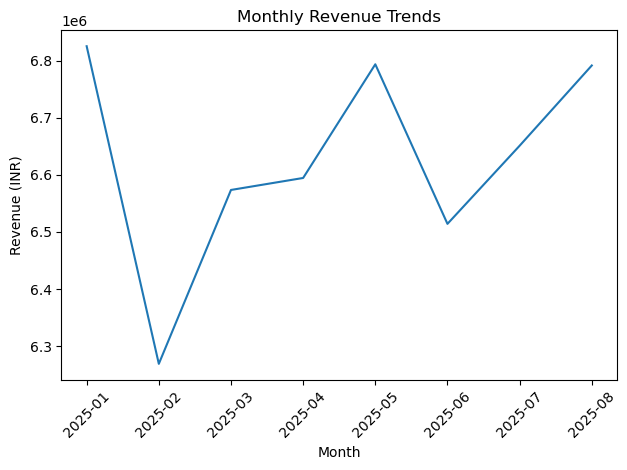

In [38]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["YearMonth"] = df["Order Date"].dt.to_period("M").astype(str)

monthly_revenue = df.groupby("YearMonth")["Price (INR)"].sum().reset_index()

plt.figure()
plt.plot(monthly_revenue["YearMonth"],monthly_revenue["Price (INR)"])
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Revenue (INR)")
plt.title("Monthly Revenue Trends")
plt.tight_layout()
plt.show()


### Daily Sales Trends

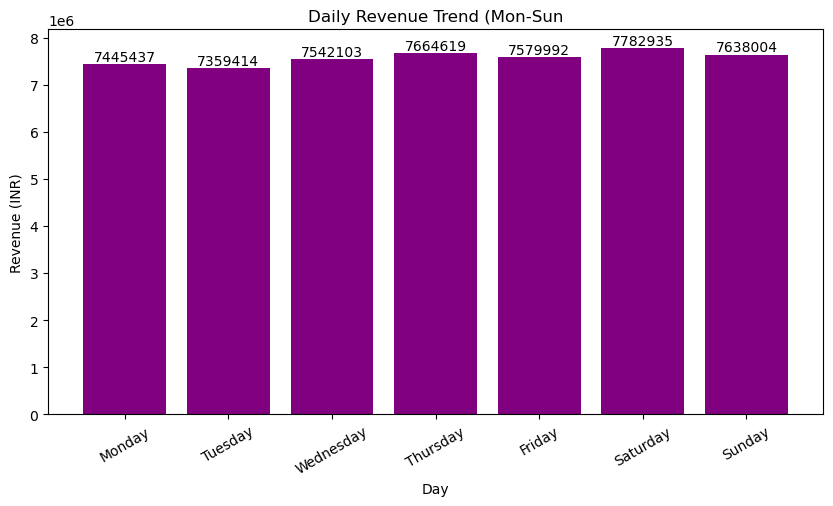

In [40]:
df["DayName"] = pd.to_datetime(df["Order Date"]).dt.day_name()

daily_revenue = (
     df.groupby("DayName")["Price (INR)"]
       .sum()
       .reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
         )

plt.figure(figsize=(10,5))
for i in range(len(daily_revenue)):
    plt.text(
        i,                                
        daily_revenue.values[i],          
        int(daily_revenue.values[i]),     
        ha='center',                      
        va='bottom'     
    )
plt.bar(daily_revenue.index,daily_revenue.values,color="Purple")
plt.title("Daily Revenue Trend (Mon-Sun")
plt.xlabel("Day")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=30)

plt.show()






### Total Sales by Food Type (Veg vs Non-Veg)

In [17]:
non_veg_keywords = [
    "chicken", "egg", "fish", "mutton",
    "prawn", "biryani", "kabab", "kebab",
    "non-veg", "non veg"
]

df["Food Category"] = np.where(
    df["Dish Name"].str.lower().str.contains("|".join(non_veg_keywords), na=False),
    "Non-Veg",
    "Veg"
)

In [18]:
food_revenue = (
     df.groupby("Food Category")["Price (INR)"]
       .sum()
       .reset_index()
)

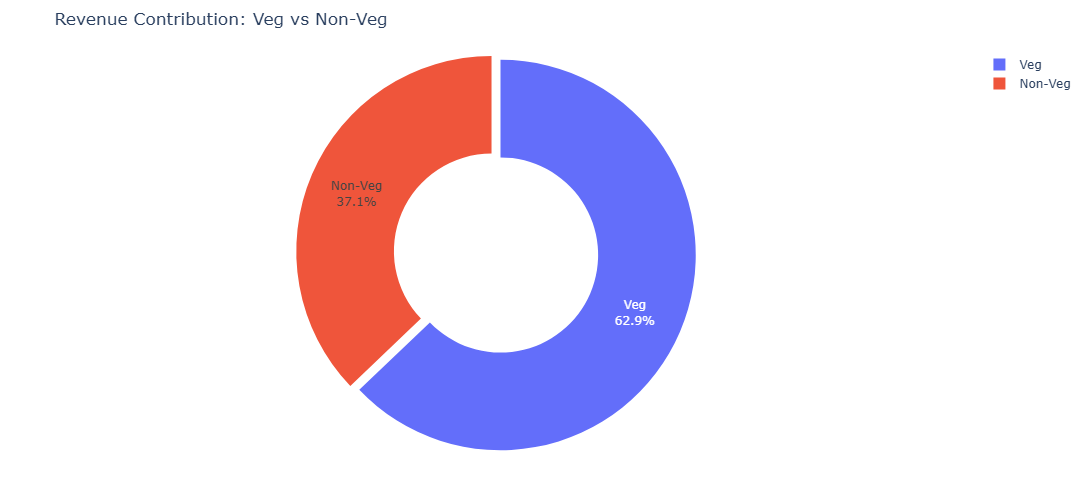

In [19]:
fig = px.pie(
    food_revenue,
    values="Price (INR)",
    names="Food Category",
    hole=0.5,
    title="Revenue Contribution: Veg vs Non-Veg",
)

fig.update_traces(
    textinfo="percent+label",
    pull=[0.05, 0]
)

fig.update_layout(
    height=500,
    margin=dict(t=50, b=40, l=40, r=40)
)

fig.show()

### Total Sales by State ((Map Visualization)

In [20]:
fig = px.bar(
    df.groupby("State", as_index=False)["Price (INR)"].sum()
      .sort_values("Price (INR)", ascending=False),
    x="Price (INR)",
    y="State",
    orientation="h",
    title="Revenue by State (INR)"
)

fig.update_layout(height=600, yaxis=dict(autorange="reversed"))
fig.show()

### Quarterly Performance Summary 

In [21]:
df["Order_Date"] = pd.to_datetime(df["Order Date"])
df["Quarter"] = df["Order_Date"].dt.to_period("Q").astype(str)

quarterly_summary = (
    df.groupby("Quarter", as_index=False)
    .agg(
        Total_Sales=("Price (INR)", "sum"),
        Avg_Rating=("Rating", "mean"),
        Total_Orders=("Order_Date", "count")
    )
    .sort_values("Quarter")
)

quarterly_summary["Total_Sales"] = quarterly_summary["Total_Sales"].round(2)
quarterly_summary["Avg_Rating"] = quarterly_summary["Avg_Rating"].round(2)

quarterly_summary

,Quarter,Total_Sales,Avg_Rating,Total_Orders
0,2025Q1,19667821.77,4.34,73096
1,2025Q2,19902256.59,4.34,74163
2,2025Q3,13442427.41,4.34,50171


### Top 5 Cities by Sales

In [22]:
top_5_cities = (
    df.groupby("City")["Price (INR)"]
    .sum()
    .nlargest(5)
    .sort_values()
    .reset_index()
)

fig = px.bar(
    top_5_cities,
    x="Price (INR)",
    y="City",
    orientation="h",
    title="Top 5 Cities by Sales (INR)",
    color_discrete_sequence=["red"]
)

fig.show()

### Weekly Trend Analysis

In [23]:
df["Order_Date"] = pd.to_datetime(df["Order Date"])
df["Day"] = df["Order_Date"].dt.day_name()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

weekly_sales = (
    df.groupby("Day", as_index=False)["Price (INR)"]
    .sum()
)

fig = px.bar(
    weekly_sales,
    x="Day",
    y="Price (INR)",
    category_orders={"Day": day_order}, 
    title="Weekly Sales Trend",
    color="Price (INR)"
)

fig.show()